# Smart City Traffic Forecasting

## Objective

The objective of this project is to predict the number of vehicles passing through different traffic junctions using historical traffic data.

This notebook focuses on understanding the dataset before cleaning, visualization, and model building.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

%matplotlib inline

train = pd.read_csv("../data/raw/train_aWnotuB.csv")
test = pd.read_csv("../data/raw/test_BdBKkAj.csv")

train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [2]:
train.tail()

,DateTime,Junction,Vehicles,ID
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224
48119,2017-06-30 23:00:00,4,12,20170630234


In [3]:
train.shape

(48120, 4)

In [4]:
train.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='str')

In [5]:
train['DateTime'] = pd.to_datetime(train['DateTime'])
train.dtypes

DateTime    datetime64[us]
Junction             int64
Vehicles             int64
ID                   int64
dtype: object

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   DateTime  48120 non-null  datetime64[us]
 1   Junction  48120 non-null  int64         
 2   Vehicles  48120 non-null  int64         
 3   ID        48120 non-null  int64         
dtypes: datetime64[us](1), int64(3)
memory usage: 1.5 MB


## Observations from train.info()

- The dataset contains **48,120 rows** and **4 columns**.
- `DateTime` has been successfully converted to `datetime64`, enabling time-based analysis.
- `Junction`, `Vehicles`, and `ID` are stored as integer values.
- No missing values are present in any column.
- The dataset occupies approximately **1.5 MB** of memory.

In [7]:
train.describe()

,DateTime,Junction,Vehicles,ID
count,48120,48120.000000,48120.000000,4.812000e+04
mean,2016-09-19 06:03:56.109725,2.180549,22.791334,2.016330e+10
min,2015-11-01 00:00:00,1.000000,1.000000,2.015110e+10
25%,2016-04-16 01:45:00,1.000000,9.000000,2.016042e+10
50%,2016-09-30 03:30:00,2.000000,15.000000,2.016093e+10
75%,2017-02-25 16:00:00,3.000000,29.000000,2.017023e+10
max,2017-06-30 23:00:00,4.000000,180.000000,2.017063e+10
std,NaN,0.966955,20.750063,5.944854e+06


## Observations from `describe()`

- The dataset contains **48,120 observations**.
- Vehicle counts range from **1 to 180**, indicating significant variation in traffic.
- The average traffic volume is **22.79 vehicles**, while the median is **15 vehicles**, suggesting that the distribution may be right-skewed.
- The dataset contains traffic information from **4 different junctions**.
- The data covers the period from **November 2015 to June 2017**.
- The high variation in vehicle counts indicates that traffic changes considerably over time, making forecasting an appropriate machine learning problem.

In [8]:
# Check missing values
train.isnull().sum()

# Check duplicate rows
train.duplicated().sum()

# Check unique values in Junction
train['Junction'].unique()

# Count records in each Junction
train['Junction'].value_counts()

Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

## Observation

The dataset contains traffic data from four junctions.

- Junction 1: 14,592 records
- Junction 2: 14,592 records
- Junction 3: 14,592 records
- Junction 4: 4,344 records

Junction 4 has significantly fewer records than the other three junctions. This difference should be investigated during exploratory data analysis (EDA).

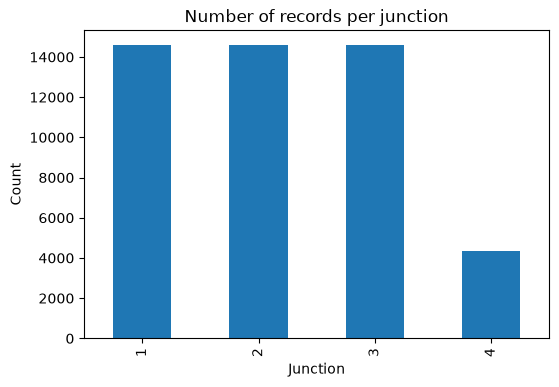

In [9]:
train['Junction'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Number of records per junction")
plt.xlabel("Junction")
plt.ylabel("Count")
plt.show()

## Observation: Records per Junction

The bar chart shows the distribution of records across the four traffic junctions.

- Junctions 1, 2, and 3 each contain approximately **14,592** observations.
- Junction 4 contains only **4,344** observations.
- This indicates that the dataset is imbalanced with respect to Junction 4.
- Further analysis is required to determine whether the reduced number of records is due to later data collection, missing observations, or other factors.

In [10]:
train['Year'] = train['DateTime'].dt.year
train['Month'] = train['DateTime'].dt.month
train['Day'] = train['DateTime'].dt.day
train['Hour'] = train['DateTime'].dt.hour
train.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4


In [11]:
train['DayOfWeek'] = train['DateTime'].dt.dayofweek
train[['DateTime', 'DayOfWeek']].head(10)

,DateTime,DayOfWeek
0,2015-11-01 00:00:00,6
1,2015-11-01 01:00:00,6
2,2015-11-01 02:00:00,6
3,2015-11-01 03:00:00,6
4,2015-11-01 04:00:00,6
5,2015-11-01 05:00:00,6
6,2015-11-01 06:00:00,6
7,2015-11-01 07:00:00,6
8,2015-11-01 08:00:00,6
9,2015-11-01 09:00:00,6


In [12]:
train['Weekend'] = train['DayOfWeek'].apply(lambda x:1 if x>=5 else 0)
train[['DateTime', 'DayOfWeek', 'Weekend']].head(10)


,DateTime,DayOfWeek,Weekend
0,2015-11-01 00:00:00,6,1
1,2015-11-01 01:00:00,6,1
2,2015-11-01 02:00:00,6,1
3,2015-11-01 03:00:00,6,1
4,2015-11-01 04:00:00,6,1
5,2015-11-01 05:00:00,6,1
6,2015-11-01 06:00:00,6,1
7,2015-11-01 07:00:00,6,1
8,2015-11-01 08:00:00,6,1
9,2015-11-01 09:00:00,6,1


In [13]:
hourly_traffic = train.groupby('Hour')["Vehicles"].mean()
hourly_traffic

Hour
0     23.540648
1     19.654863
2     17.102743
3     14.847382
4     12.973067
5     12.173566
6     12.980050
7     14.703242
8     16.402993
9     19.379551
10    24.229925
11    27.495262
12    28.403990
13    25.588529
14    27.702743
15    27.650374
16    26.674314
17    26.648379
18    28.095262
19    29.854863
20    29.824938
21    28.202993
22    27.226933
23    25.635411
Name: Vehicles, dtype: float64

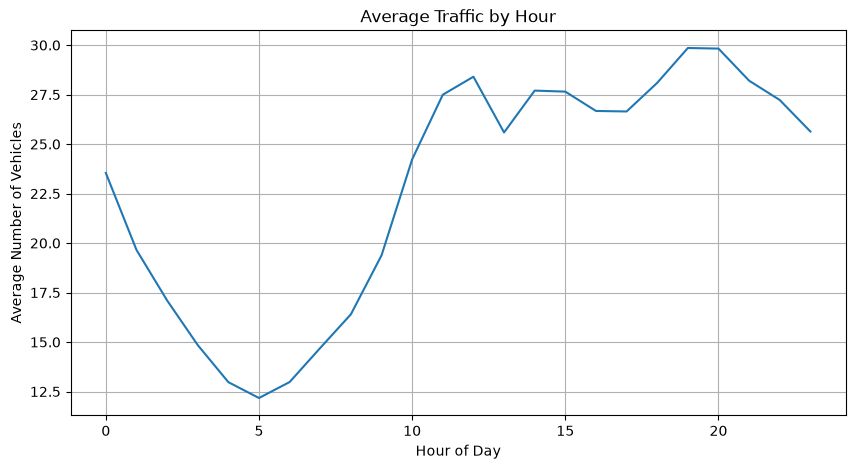

In [14]:
hourly_traffic.plot(figsize=(10,5))

plt.title("Average Traffic by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Number of Vehicles")

plt.grid(True)

plt.show()

## Observation: Average Traffic by Hour

- Traffic is lowest during the early morning hours (approximately 4 AM to 6 AM).
- Traffic begins to increase after 7 AM.
- The highest average traffic occurs around 7 PM and 8 PM (19:00–20:00).
- After 8 PM, traffic gradually decreases.
- The graph indicates a clear daily traffic pattern, suggesting that the Hour feature will be highly useful for forecasting vehicle counts.

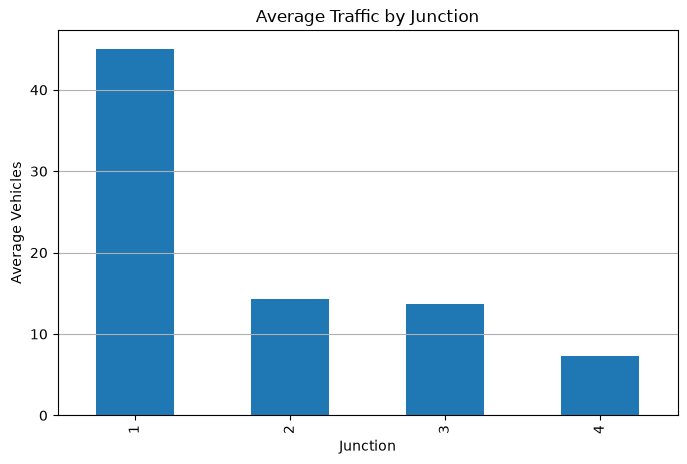

In [15]:
junction_traffic = train.groupby('Junction')['Vehicles'].mean()
junction_traffic

junction_traffic.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Average Traffic by Junction")
plt.xlabel("Junction")
plt.ylabel("Average Vehicles")
plt.grid(axis='y')

plt.show()

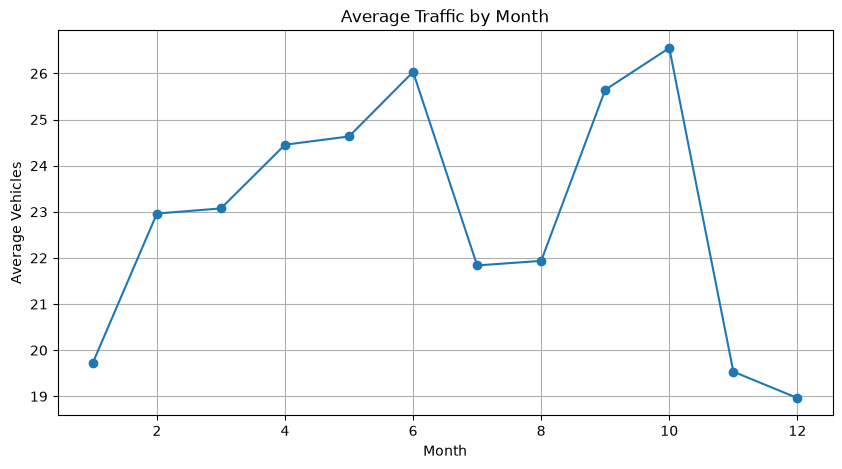

In [16]:
monthly_traffic = train.groupby('Month')["Vehicles"].mean()

monthly_traffic.plot(kind='line',marker ='o',figsize=(10,5))
plt.title("Average Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Average Vehicles")
plt.grid(True)
plt.show()

## Observation: Average Traffic by Month

- Traffic varies across different months.
- The highest average traffic is observed in **October (Month 10)**.
- The lowest average traffic is observed in **December (Month 12)**.
- Traffic generally increases from January to June, decreases during July and August, rises again in September and October, and declines towards the end of the year.
- This indicates that the `Month` feature captures seasonal patterns and may be useful for traffic forecasting.

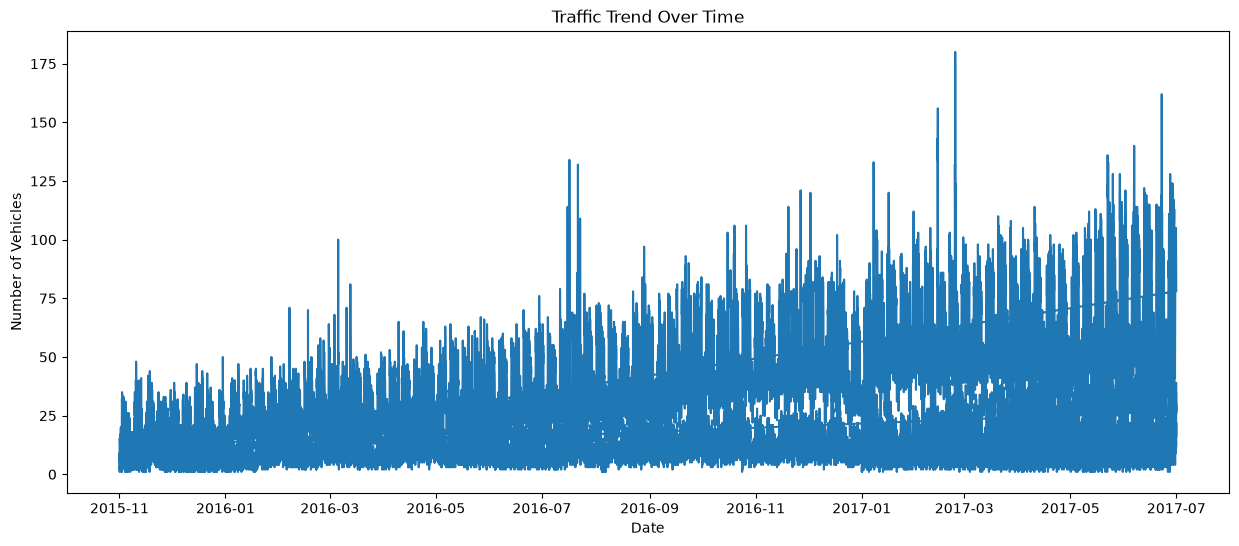

In [17]:
plt.figure(figsize=(15,6))

plt.plot(train['DateTime'], train['Vehicles'])

plt.title("Traffic Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Vehicles")

plt.show()

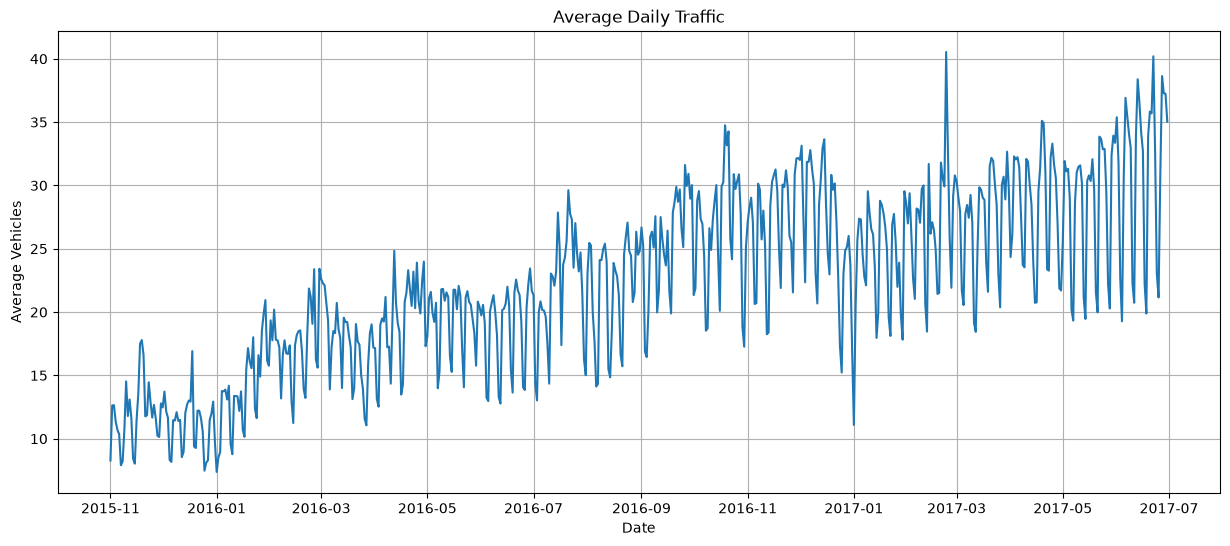

In [18]:
daily_traffic = train.groupby(train['DateTime'].dt.date)['Vehicles'].mean()
plt.figure(figsize=(15,6))

plt.plot(daily_traffic)

plt.title("Average Daily Traffic")
plt.xlabel("Date")
plt.ylabel("Average Vehicles")

plt.grid(True)

plt.show()

## Observation: Average Daily Traffic

- The average daily traffic exhibits an overall upward trend over the observation period.
- Although the long-term trend is increasing, there are frequent short-term fluctuations.
- These fluctuations may be caused by recurring traffic patterns such as weekdays versus weekends or other daily variations.
- The presence of both trend and fluctuations suggests that traffic forecasting models should capture both long-term growth and short-term temporal patterns.

In [20]:
# Create additional time-based features

train['Quarter'] = train['DateTime'].dt.quarter
train['WeekOfYear'] = train['DateTime'].dt.isocalendar().week.astype(int)

test['DateTime'] = pd.to_datetime(test['DateTime'])

test['Year'] = test['DateTime'].dt.year
test['Month'] = test['DateTime'].dt.month
test['Day'] = test['DateTime'].dt.day
test['Hour'] = test['DateTime'].dt.hour
test['DayOfWeek'] = test['DateTime'].dt.dayofweek
test['Weekend'] = test['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
test['Quarter'] = test['DateTime'].dt.quarter
test['WeekOfYear'] = test['DateTime'].dt.isocalendar().week.astype(int)

In [21]:
features = [
    'Junction',
    'Year',
    'Month',
    'Day',
    'Hour',
    'DayOfWeek',
    'Weekend',
    'Quarter',
    'WeekOfYear'
]

X = train[features]
y = train['Vehicles']

X_test = test[features]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [24]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

pred = model.predict(X_valid)

print("MAE :", mean_absolute_error(y_valid, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, pred)))
print("R2 Score:", r2_score(y_valid, pred))

MAE : 2.373033042394015
RMSE: 3.536191401202028
R2 Score: 0.9693172628369957


In [25]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,Junction,0.516427
1,Year,0.166747
4,Hour,0.143521
5,DayOfWeek,0.045039
8,WeekOfYear,0.039061
2,Month,0.028971
6,Weekend,0.027467
3,Day,0.021843
7,Quarter,0.010924


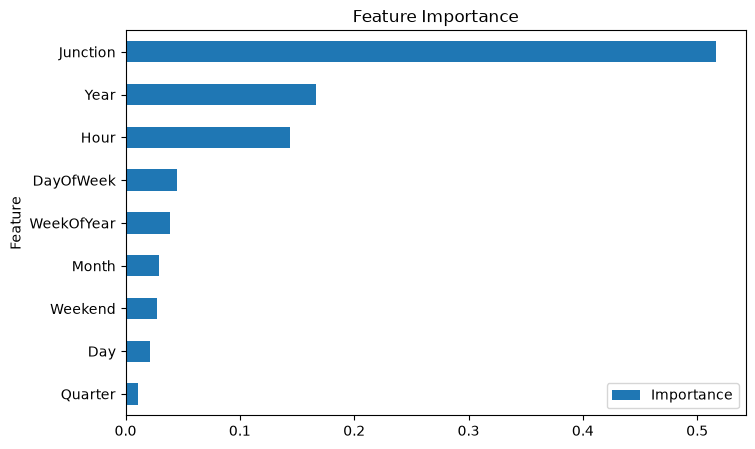

In [26]:
import matplotlib.pyplot as plt

importance.sort_values(by='Importance').plot(
    x='Feature',
    y='Importance',
    kind='barh',
    figsize=(8,5)
)

plt.title("Feature Importance")
plt.show()

In [27]:
test_predictions = model.predict(X_test)

In [28]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "Vehicles": test_predictions
})

submission.head()

,ID,Vehicles
0,20170701001,69.120
1,20170701011,57.500
2,20170701021,43.845
3,20170701031,38.220
4,20170701041,32.630


In [ ]:
submission.to_csv("submission.csv", index=False)


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

from sklearn.metrics import mean_absolute_error

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)

    print("--------------------------------")
    print(name)
    print("MAE:", mean_absolute_error(y_valid, pred))

--------------------------------
Linear Regression
MAE: 9.579420948217898
--------------------------------
Decision Tree
MAE: 3.0740856192851207
--------------------------------
Random Forest
MAE: 2.3802784704904405


In [31]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']